In [1]:
import copy
import heapq
import math
import random
from collections import defaultdict
from itertools import chain
import geopandas as gpd
from shapely.geometry import LineString, Polygon

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from tqdm import trange
# from deap import base, creator, tools, algorithms
import numpy as np

In [2]:

# Drone specifications
drone_spec = {
    '103': {'drone_name': "Freefly Alta X", 'fly_time': 20 / 60, 'Payload': 15, 'Speed': 25 * 3.6, 'Battery_mAh': 20000, 'Energy_meter': 7, 'Cost_per_energy': 3},
    '104': {'drone_name': "JOUAV CW-80E", 'fly_time': 20 / 60, 'Payload': 10, 'Speed': 20 * 3.6, 'Battery_mAh': 15000, 'Energy_meter': 6.5, 'Cost_per_energy': 2.78},
    '105': {'drone_name': "Draganfly Heavy Lift Drone", 'fly_time': 23 / 60, 'Payload': 30, 'Speed': 17 * 3.6, 'Battery_mAh': 27000, 'Energy_meter': 10, 'Cost_per_energy': 4.2},
    '106': {'drone_name': "DJI FlyCart", 'fly_time': 30 / 60, 'Payload': 18, 'Speed': 20 * 3.6, 'Battery_mAh': 23000, 'Energy_meter': 8, 'Cost_per_energy': 3.4},
    '107': {'drone_name': "Harris Aerial Carrier H6 HL", 'fly_time': 20 / 60, 'Payload': 40, 'Speed': 15 * 3.6, 'Battery_mAh': 30000, 'Energy_meter': 11, 'Cost_per_energy': 4.7}
}

# Scaling factor
scaling_factor = 0.1

# deli_locations and warehouse locations in kilometers (km), scaled down by a factor
location = [
    (6.75859879717907 * scaling_factor, 24.1011220595671 * scaling_factor),
    (64.2020211216308 * scaling_factor, 21.2780005223912 * scaling_factor),
    (3.28223545665507 * scaling_factor, 58.3280585995255 * scaling_factor),
    (0.356408133450226 * scaling_factor, 71.2535984441914 * scaling_factor),
    (47.5416279589111 * scaling_factor, 57.2421947321968 * scaling_factor),
    (54.1391723668124 * scaling_factor, 10.1630144708565 * scaling_factor),
    (5.16311785475916 * scaling_factor, 18.3713689888664 * scaling_factor),
    (58.1077341232713 * scaling_factor, 97.325872003479 * scaling_factor),
    (22.3719171429327 * scaling_factor, 94.5307472331531 * scaling_factor),
    (10.9215147296463 * scaling_factor, 26.9026260431418 * scaling_factor),
    (40.2830425950062 * scaling_factor, 49.0059611185157 * scaling_factor),
    (95.9067950103118 * scaling_factor, 31.2537921390593 * scaling_factor),
    (38.8068853736467 * scaling_factor, 61.8496341187066 * scaling_factor),
    (50.7736281603872 * scaling_factor, 41.7122988413166 * scaling_factor),
    (16.1210451723109 * scaling_factor, 4.17415211185698 * scaling_factor),
    (30.5725260368337 * scaling_factor, 25.6641613944403 * scaling_factor),
    (88.6541848293903 * scaling_factor, 28.6034058450262 * scaling_factor),
    (76.1583329812348 * scaling_factor, 52.0601020081577 * scaling_factor),
    (57.9907902884404 * scaling_factor, 58.2901693224847 * scaling_factor),
    (80.1180100459334 * scaling_factor, 80.7424210060046 * scaling_factor),
    (99.879027610417 * scaling_factor, 99.9769056531731 * scaling_factor),
    (2.58720752188314 * scaling_factor, 45.8084939684228 * scaling_factor),
    (74.0498005304951 * scaling_factor, 2.98613115772289 * scaling_factor),
]

warehouse_locations = [
    (71.7091166549543 * scaling_factor, 17.2581705831028 * scaling_factor),
    (16.6066387616466 * scaling_factor, 73.6752906752222 * scaling_factor),
]

# deli_locations weights in kilograms (kg)
loc_wght = [
    1.5, 2.5, 2.5, 2.0, 2.0, 3.0, 1.0, 3.0, 0.5, 3.5, 1.0, 2.0, 0.0, 3.0, 0.0, 2.0, 0.0, 1.5, 1.0, 2.5, 0.5, 2.0, 1.5
]

# No-Fly Zones as polygons (each polygon is a list of vertices)
no_fly_zones = [
    [(6, 6), (6, 8), (8, 8), (8, 6)],  # Near the top-right corner, affecting nearby deli_locationss
    [(2, 2), (2, 3.5), (3.5, 3.5), (3.5, 2)],  # Near the bottom-left, close to other deli_locationss
]


In [3]:
RS_SIZE = 2  # Random search size

no_fly_gdf = gpd.GeoDataFrame(geometry=[Polygon(zone) for zone in no_fly_zones])

def distance_between_locations(p1, p2):
    """Calculate distance between two given coordinates"""
    return math.sqrt(math.pow(p1[0] - p2[0], 2) + math.pow(p1[1] - p2[1], 2))

def is_path_intersecting_no_fly_zones(p1, p2, no_fly_gdf):
    """Check if the path from p1 to p2 intersects with any no-fly zones using GeoPandas."""
    path = LineString([p1, p2])

    # Create GeoSeries for the path
    path_gs = gpd.GeoSeries(path)

    # Check for intersections
    intersections = no_fly_gdf.intersects(path_gs.iloc[0])

    return intersections.any()

def is_tour_valid_ga(tour, graph):
    """
    Check if the entire tour is valid, i.e., no segment of the tour intersects any no-fly zones.

    Args:
        tour: List of indices representing the tour.
        graph: Graph object containing vertices (locations).

    Returns:
        bool: True if the tour is valid, False otherwise.
    """
    coordinates = [graph.vertices[i] for i in tour]

    for i in range(len(coordinates) - 1):
        p1 = coordinates[i]
        p2 = coordinates[i + 1]

        if is_path_intersecting_no_fly_zones(p1, p2, no_fly_gdf):
            return False  # Invalid if any segment intersects a no-fly zone

    return True  # Valid if no segments intersect



In [4]:

class Graph:
    def __init__(self, vertices):
        self.vertices = vertices
        self.n = len(vertices)

    def x(self, v):
        return self.vertices[v][0]

    def y(self, v):
        return self.vertices[v][1]

    _d_lookup = {}

    def d(self, u, v):
        if (u, v) in self._d_lookup:
            return self._d_lookup[(u, v)]
        _distance = math.sqrt((u[0] - v[0]) ** 2 + (u[1] - v[1]) ** 2)
        self._d_lookup[(u, v)], self._d_lookup[(v, u)] = _distance, _distance
        return _distance


In [5]:
class Tour:
    def __init__(self, g, vertices=None):
        self.g = g
        self.vertices = vertices if vertices is not None else list(range(1, g.n))
        random.shuffle(self.vertices)
        self.__cost = None

    def cost(self):
        if self.__cost is None:
            self.__cost = 0
            for i, j in zip([0] + self.vertices, self.vertices + [0]):
                self.__cost += self.g.d(self.g.vertices[i], self.g.vertices[j])
        return self.__cost

    def to_list(self):
        return self.vertices






In [6]:
class GeneticAlgorithm:
    def __init__(self, g,population_size, drone_id, generations=200, mutation_rate=0.1, mutation_swap_rate=0.2):
        self.g = g
        self.population_size = population_size
        self.generations = int(generations)
        self.drone_id = drone_id
        self.mutation_rate = mutation_rate
        self.mutation_swap_rate = mutation_swap_rate
        self.population = [Tour(g) for _ in range(population_size)]
        self.best_route = None

    def crossover(self, mum, dad):
        size = len(mum.vertices)
        alice, bob = [-1] * size, [-1] * size
        start, end = sorted([random.randrange(size) for _ in range(2)])

        for i in range(start, end + 1):
            alice[i] = mum.vertices[i]
            bob[i] = dad.vertices[i]

        current_dad_position, current_mum_position = 0, 0

        for i in chain(range(start), range(end + 1, size)):
            while dad.vertices[current_dad_position] in alice:
                current_dad_position += 1
            while mum.vertices[current_mum_position] in bob:
                current_mum_position += 1
            alice[i] = dad.vertices[current_dad_position]
            bob[i] = mum.vertices[current_mum_position]

        return Tour(self.g, alice), Tour(self.g, bob)

    def mutate(self, tour):
        """Randomly swaps pairs of cities in a given tour according to mutation rate, while avoiding no-fly zones."""
        if random.random() < self.mutation_rate:
            for i in range(len(tour.vertices)):
                if random.random() < self.mutation_swap_rate:
                    j = random.randrange(len(tour.vertices))
                    new_tour = tour.vertices[:]
                    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]

                    # Check if the new tour after the swap is valid
                    if is_tour_valid_ga(new_tour, self.g):
                        # If valid, apply the mutation
                        tour.vertices[i], tour.vertices[j] = tour.vertices[j], tour.vertices[i]
                    else:
                        # If not valid, discard the entire new tour by not updating the original tour
                        continue  # This keeps the original tour unchanged


    def selection(self):
        return heapq.nsmallest(2, self.population, key=lambda t: self.calculate_fitness(t))

    def calculate_fitness(self, tour):
        total_distance = 0
        total_weight = 0
        total_energy_cost = 0
        total_penalty = 0
        weight_time=0.5
        weight_energy=0.5
        drone = drone_spec[self.drone_id]

        for i in range(len(tour.vertices) - 1):
            src = self.g.vertices[tour.vertices[i]]
            dst = self.g.vertices[tour.vertices[i + 1]]

            if is_path_intersecting_no_fly_zones(src, dst, no_fly_gdf):
                total_penalty += float('inf') # Apply a penalty instead of returning infinity
                break

            dist = distance_between_locations(src, dst)
            total_distance += dist

            if tour.vertices[i] in range(1, len(location) + 1):
                total_weight += loc_wght[tour.vertices[i] - 1]

            energy_used = dist * drone['Energy_meter']
            total_energy_cost += energy_used * drone['Cost_per_energy']

        return_to_warehouse_dist = distance_between_locations(self.g.vertices[tour.vertices[-1]], self.g.vertices[0])
        total_distance += return_to_warehouse_dist

        total_time = total_distance / drone['Speed']

        if total_time > drone['fly_time']:
            total_penalty += 1000 * (total_time - drone['fly_time'])

        if total_weight > drone['Payload']:
            total_penalty += 1000 * (total_weight - drone['Payload'])

        fitness = (weight_energy*total_energy_cost) + (total_time*weight_time) + total_penalty
        return fitness

    def evolve(self):
        new_population = []

        for _ in range(self.population_size // 2):
            mum, dad = self.selection()
            child1, child2 = self.crossover(mum, dad)
            self.mutate(child1)
            self.mutate(child2)
            new_population.extend([child1, child2])

        self.population = new_population
        self.best_route = min(self.population, key=lambda t: self.calculate_fitness(t))

        best_fitness = self.calculate_fitness(self.best_route)
        # print(f"Best fitness this generation: {best_fitness}")

        if best_fitness == float('inf'):
            print("No valid routes found in this generation. Adjusting parameters or breaking early.")
            return

    def run(self):
        for generation in range(self.generations):
            # print(f"Generation {generation + 1}/{self.generations}")
            self.evolve()
            if self.calculate_fitness(self.best_route) == float('inf'):
                print("Terminating early due to invalid solutions.")
                break

    def best(self):
        return self.best_route


In [7]:

class WarehouseManager:
    def __init__(self):
        self.drone_spec = drone_spec
        self.routes = []
        self.drone_choices = []
        self.route_details = []
        self.deli_locations_short_list = copy.deepcopy(location)
        self.no_progress_iterations = 0
        self.max_no_progress_iterations = 10
        self.rand_drone_id = 0

    def find_initial_routes(self):
        while self.deli_locations_short_list:
            self.rand_drone_id = random.choice(list(self.drone_spec.keys()))
            drone_choice = self.drone_spec[self.rand_drone_id]
            self.drone_choices.append(drone_choice['drone_name'])
            v_chosen_fly_time = drone_choice['fly_time']
            v_chosen_payload = drone_choice['Payload']
            w_choice = random.choice(warehouse_locations)
            s_choices = []
            dist_s_choices = 0
            wght_s_choices = 0
            choice_loc = w_choice

            deli_locations_dists_from_warehouse = [distance_between_locations(w_choice, x) for x in self.deli_locations_short_list]
            max_deli_locations_distance = max(deli_locations_dists_from_warehouse)
            normalized_deli_locations_distances_rev = [1 - (float(i) / max_deli_locations_distance) for i in deli_locations_dists_from_warehouse]

            for deli_loc, dist in zip(self.deli_locations_short_list[:], normalized_deli_locations_distances_rev):
                new_dist = distance_between_locations(choice_loc, deli_loc)
                new_wght = loc_wght[location.index(deli_loc)]
                time_for_this_leg = (dist_s_choices + new_dist) / drone_choice['Speed']

                return_to_warehouse_dist = distance_between_locations(deli_loc, w_choice)
                projected_total_time = (dist_s_choices + new_dist + return_to_warehouse_dist) / drone_choice['Speed']

                if is_path_intersecting_no_fly_zones(choice_loc, deli_loc, no_fly_gdf):
                    continue  # Skip this deli_locations if the path intersects a no-fly zone

                if projected_total_time > v_chosen_fly_time:
                    continue
                if (wght_s_choices + new_wght) > v_chosen_payload:
                    continue

                s_choices.append(deli_loc)
                dist_s_choices += new_dist
                choice_loc = deli_loc
                self.deli_locations_short_list.remove(deli_loc)

            if not s_choices:
                break

            return_to_warehouse_dist = distance_between_locations(choice_loc, w_choice)
            total_distance = dist_s_choices + return_to_warehouse_dist
            total_time = total_distance / drone_choice['Speed']
            total_cost = dist_s_choices * drone_choice['Energy_meter'] * drone_choice['Cost_per_energy']

            route = [w_choice] + s_choices + [w_choice]

            if not self.is_route_valid(route):
                continue

            else:
                self.routes.append(route)

                self.route_details.append({
                    'drone_id': self.rand_drone_id,
                    'drone_name': drone_choice['drone_name'],
                    'time_taken': total_time,
                    'total_weight': wght_s_choices,
                    'total_cost': total_cost,
                    'order_of_deli_locationss': [location.index(s) + 1 for s in s_choices]
                })

    def plot_routes(self, routes, title='Routes'):
        colours = list(mcolors.TABLEAU_COLORS.keys())

        plt.figure(figsize=(10, 8))
        for n, route in enumerate(routes):
            _route = route + [route[0]]
            plt.plot(*list(zip(*_route)), c=colours[n % len(colours)], label=f'Route {n + 1}')

        plt.scatter(*zip(*location), c='blue', s=30, label='deli_locationss')
        plt.scatter(*zip(*warehouse_locations), c='red', s=100, marker="s", label='Warehouses')

        for zone in no_fly_zones:
            polygon = Polygon(zone)
            x, y = polygon.exterior.xy
            plt.fill(x, y, color='orange', alpha=0.5, label='No-Fly Zone')

        plt.legend(loc="best")
        plt.title(title)
        plt.xlabel('X coordinate')
        plt.ylabel('Y coordinate')
        plt.grid(True)
        plt.show()

    def get_warehouse_stats(self):
        w_deli_locationss_map = defaultdict(list)
        w_vehicle_map = defaultdict(list)
        for route, vehicle in zip(self.routes, self.drone_choices):
            wh = None
            route_copy = copy.deepcopy(route)
            if warehouse_locations[0] in route_copy:
                wh = 'W1'
                route_copy.remove(warehouse_locations[0])
            elif warehouse_locations[1] in route_copy:
                wh = 'W2'
                route_copy.remove(warehouse_locations[1])
            w_vehicle_map[wh].append(vehicle)
            for deli_locations in route_copy:
                w_deli_locationss_map[wh].append(deli_locations)
        return w_deli_locationss_map, w_vehicle_map


    def is_route_valid(self,route):
        """Checks if an entire route is valid (i.e., does not intersect any no-fly zones)"""
        for i in range(len(route) - 1):
            if is_path_intersecting_no_fly_zones(route[i], route[i+1], no_fly_gdf):
                return False
        return True
    def is_tour_valid_ga(tour, graph):
        """
        Check if the entire tour is valid, i.e., no segment of the tour intersects any no-fly zones.

        Args:
            tour: List of indices representing the tour.
            graph: Graph object containing vertices (locations).
            no_fly_zones: List of no-fly zones as polygons.

        Returns:
            bool: True if the tour is valid, False otherwise.
        """
        # Convert tour indices to coordinates
        coordinates = [graph.vertices[i] for i in tour]

        # Check each segment of the tour
        for i in range(len(coordinates) - 1):
            p1 = coordinates[i]
            p2 = coordinates[i + 1]

            if is_path_intersecting_no_fly_zones(p1, p2, no_fly_gdf):
                return False  # Invalid if any segment intersects a no-fly zone

        return True  # Valid if no segments intersect


    def optimize_routes(self):
        for i in range(len(self.routes)):
            g = Graph(self.routes[i])
            drone_id = self.route_details[i]['drone_id']
            ga = GeneticAlgorithm(g,100, drone_id)
            ga.run()
            optimize_route = ga.best().to_list()

            # Set weights as needed, for example:
            weight_time = 0.5
            weight_energy = 0.5
            # Correct mapping of optimized route
            optimized_route_indices = [self.routes[i][x] for x in optimize_route]
            self.routes[i] = optimized_route_indices
            self.route_details[i]['order_of_deli_locationss'] = [location.index(loc) + 1 for loc in optimized_route_indices if loc in location]

            # Recalculate the total time and cost for the optimized route
            total_distance = 0
            total_energy_cost = 0
            current_payload = sum([loc_wght[location.index(loc)] for loc in self.routes[i] if loc in location])

            for x in range(len(self.routes[i]) - 1):
                src = self.routes[i][x]
                dst = self.routes[i][x + 1]
                dist_km = distance_between_locations(src, dst)
                total_distance += dist_km

                # Energy used in this segment is calculated using the current payload and the distance in km
                energy_used = dist_km * self.drone_spec[drone_id]['Energy_meter'] * current_payload
                total_energy_cost += energy_used * self.drone_spec[drone_id]['Cost_per_energy']

                # If the destination is a deli_locations, reduce the payload after delivery
                if dst in location:
                    delivery_weight = loc_wght[location.index(dst)]
                    current_payload -= delivery_weight

            # Calculate return trip to warehouse
            return_to_warehouse_dist_km = distance_between_locations(self.routes[i][-1], self.routes[i][0])
            total_distance += return_to_warehouse_dist_km

            # Energy cost for the return trip with the remaining payload
            if current_payload == 0:
                # If no payload, use constant energy meter value of 2
                energy_used = return_to_warehouse_dist_km * 2
            else:
                energy_used = return_to_warehouse_dist_km * self.drone_spec[drone_id]['Energy_meter'] * current_payload

            total_energy_cost += energy_used * self.drone_spec[drone_id]['Cost_per_energy']

            total_time = total_distance / self.drone_spec[drone_id]['Speed']
            
            self.route_details[i]['time_taken'] = total_time
            self.route_details[i]['total_cost'] = total_energy_cost


    def calculate_travel_cost(self):
        """calculates cost"""
        return sum([rd['total_cost'] for rd in self.route_details])

    def calculate_travel_time(self):
        """calculates time taken"""
        return sum([rd['time_taken'] for rd in self.route_details])




In [8]:
def pretty_print_results():
    def get_deli_locations_label(deli_locations_location):
        return location.index(deli_locations_location) + 1

    wh_deli_locationss_map, wh_vehicle_map = best_warehouse_manager.get_warehouse_stats()
    for wh, deli_locationss in wh_deli_locationss_map.items():
        deli_locations_labels = [get_deli_locations_label(s) for s in deli_locationss]
        print(f'Warehouse {wh} supply deli_locationss: {deli_locations_labels}')
    for wh, vehicles in wh_vehicle_map.items():
        print(f'Warehouse {wh} needs the following drones: {vehicles}')
    print(f'Travel cost = {best_travel_cost} ')
    print(f'Travel time = {best_travel_time}')

    for i, details in enumerate(best_warehouse_manager.route_details):
        print(f"Route {i + 1}: Drone {details['drone_name']}, Time: {details['time_taken']*60:.2f} min, Weight: {details['total_weight']:.2f} kg, Cost: {details['total_cost']:.2f}, deli_locationss visited: {details['order_of_deli_locationss']}")

    best_warehouse_manager.plot_routes(best_warehouse_manager.routes)

  0%|          | 0/2 [00:00<?, ?it/s]

Attempt 1
Initial routes found: 5


 50%|█████     | 1/2 [1:08:30<1:08:30, 4110.12s/it]

Cost after attempt 1: 9721.972399543567 
Time after attempt 1: 1.2533300260304854
Attempt 2
Initial routes found: 5


100%|██████████| 2/2 [7:33:08<00:00, 13594.05s/it] 

Cost after attempt 2: 8194.539720064511 
Time after attempt 2: 1.2445279534251557
Warehouse W2 supply deli_locationss: [11, 5, 6, 13, 4, 1, 3, 18, 19, 8, 15, 10, 22]
Warehouse W1 supply deli_locationss: [9, 14, 2, 7, 21, 23]
Warehouse W2 needs the following drones: ['Freefly Alta X', 'Freefly Alta X', 'Freefly Alta X']
Warehouse W1 needs the following drones: ['JOUAV CW-80E', 'JOUAV CW-80E']
Travel cost = 8194.539720064511 
Travel time = 1.2445279534251557
Route 1: Drone Freefly Alta X, Time: 18.28 min, Weight: 0.00 kg, Cost: 3511.40, deli_locationss visited: [11, 5, 6, 13, 4, 1, 3]
Route 2: Drone JOUAV CW-80E, Time: 19.80 min, Weight: 0.00 kg, Cost: 1209.33, deli_locationss visited: [9, 14, 2, 7]
Route 3: Drone Freefly Alta X, Time: 17.92 min, Weight: 0.00 kg, Cost: 2715.19, deli_locationss visited: [18, 19, 8, 15, 10]
Route 4: Drone Freefly Alta X, Time: 13.48 min, Weight: 0.00 kg, Cost: 533.15, deli_locationss visited: [21, 23]
Route 5: Drone JOUAV CW-80E, Time: 5.20 min, Weight: 0.

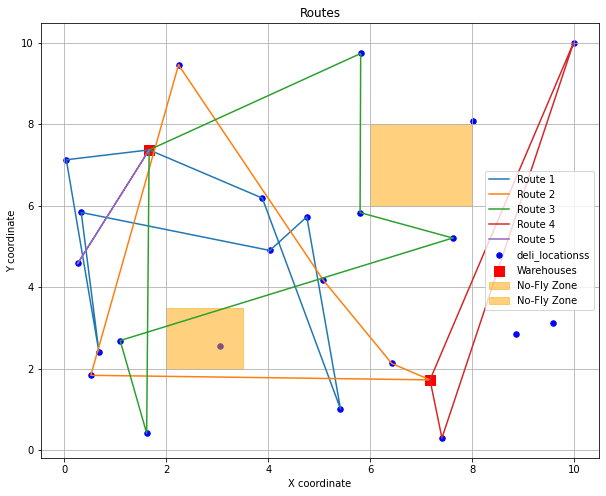

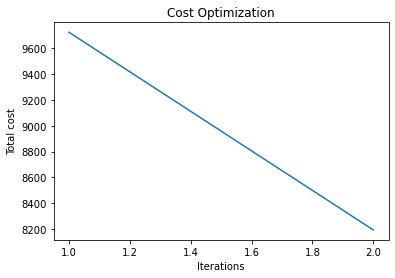

In [9]:
# Main execution starts here
best_travel_cost = 9999999
best_travel_time = 9999999
best_warehouse_manager = None
best_fitness = 9999999
weight_time = 0.5
weight_energy = 0.5
X, Y = [], []
for attempt in trange(1, RS_SIZE + 1):
    print(f"Attempt {attempt}")
    whm = WarehouseManager()
    whm.find_initial_routes()
    print(f"Initial routes found: {len(whm.routes)}")
    whm.optimize_routes()
    new_travel_cost,new_travel_time = whm.calculate_travel_cost(),whm.calculate_travel_time()
    # weighted sum of cost and time is calculated to compare and find the best optimal solution 
    new_fitness = weight_time * new_travel_time + weight_energy * new_travel_cost
    if new_fitness<best_fitness:
        best_travel_cost = new_travel_cost
        best_travel_time = new_travel_time
        best_warehouse_manager = copy.deepcopy(whm)
        best_fitness = new_fitness
    X.append(attempt)
    Y.append(best_travel_cost)
    print(f"Cost after attempt {attempt}: {new_travel_cost} ")
    print(f"Time after attempt {attempt}: {new_travel_time}")


pretty_print_results()

plt.plot(X, Y)
plt.title('Cost Optimization')
plt.xlabel('Iterations')
plt.ylabel('Total cost')
plt.show()



Warehouse W2 supply deli_locationss: [11, 5, 6, 13, 4, 1, 3, 18, 19, 8, 15, 10, 22]
Warehouse W1 supply deli_locationss: [9, 14, 2, 7, 21, 23]
Warehouse W2 needs the following drones: ['Freefly Alta X', 'Freefly Alta X', 'Freefly Alta X']
Warehouse W1 needs the following drones: ['JOUAV CW-80E', 'JOUAV CW-80E']
Travel cost = 8194.539720064511 
Travel time = 1.2445279534251557
Route 1: Drone Freefly Alta X, Time: 18.28 min, Weight: 0.00 kg, Cost: 3511.40, deli_locationss visited: [11, 5, 6, 13, 4, 1, 3]
Route 2: Drone JOUAV CW-80E, Time: 19.80 min, Weight: 0.00 kg, Cost: 1209.33, deli_locationss visited: [9, 14, 2, 7]
Route 3: Drone Freefly Alta X, Time: 17.92 min, Weight: 0.00 kg, Cost: 2715.19, deli_locationss visited: [18, 19, 8, 15, 10]
Route 4: Drone Freefly Alta X, Time: 13.48 min, Weight: 0.00 kg, Cost: 533.15, deli_locationss visited: [21, 23]
Route 5: Drone JOUAV CW-80E, Time: 5.20 min, Weight: 0.00 kg, Cost: 225.47, deli_locationss visited: [22]


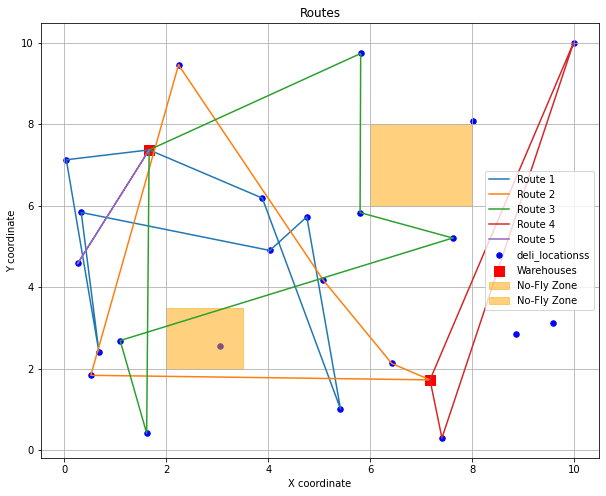

In [10]:
pretty_print_results()